<a href="https://colab.research.google.com/github/Auwal-Asumal/AUWAL_ACO-WORK/blob/main/ACO_with_best_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
import csv
import random
import sys
import math
import matplotlib.patches as mpatches
import time

# ── Section 1: Global constants and helper functions ────────────────────────

# Evaluation dataset settings
ELLIPSE_PARAMS = {
    'IMAGE_SIZE_PX': 20,           # px (fixed input image size)
    'SPACE_SIZE_MM': 40.0,         # mm (fixed physical space that the image covers)
}
ELLIPSE_PARAMS['SCALE'] = ELLIPSE_PARAMS['SPACE_SIZE_MM'] / ELLIPSE_PARAMS['IMAGE_SIZE_PX'] # mm/px

IOU_THRESHOLD = 0.7          # Threshold for IoU to consider a detection 'pass'
N_SAMPLES     = 10           # Number of images to plot in the sample visualisations
GAUSSIAN_KERNEL_SIZE = (5, 5) # Kernel size for Gaussian blur filter (e.g., (5, 5) for 5x5 kernel) for image preprocessing
CANNY_THRESH1 = 50           # Canny edge detector threshold 1
CANNY_THRESH2 = 150          # Canny edge detector threshold 2

# Ant Colony Optimization (ACO) parameters
N_ANTS     = 10
ARCHIVE_SZ = 20
N_ITERS    = 50
GAUSSIAN_PHEROMONE_KERNEL_SIZE = (1, 3) # Kernel size for Gaussian blur on pheromone matrix, (height, width)

# Dataset paths
ANNOTATIONS_JSON = "/content/ElGenV1_Ellipses_1000/annotations.json"
IMAGES_FOLDER    = "/content/ElGenV1_Ellipses_1000/Ellipses"
OUTPUT_FOLDER    = "/content/evaluation_output_aco_ellipses"

def px_to_mm(val_px): return val_px * ELLIPSE_PARAMS['SCALE']
def mm_to_px(val_mm): return val_mm / ELLIPSE_PARAMS['SCALE']

def angle_wrap_error(a1, a2): # in radians
    diff = abs(a1 - a2)
    return min(diff, 2 * np.pi - diff)

def compute_iou(e1, e2): # Renamed from calculate_iou to align with new code
    """
    Calculate IoU between two ellipses using mask-based approach.
    e1, e2: dict with center_x, center_y, semi_major_axis, semi_minor_axis, orientation_angle_rad
    """
    mask1 = np.zeros((ELLIPSE_PARAMS['IMAGE_SIZE_PX'], ELLIPSE_PARAMS['IMAGE_SIZE_PX']), dtype=np.uint8)
    mask2 = np.zeros((ELLIPSE_PARAMS['IMAGE_SIZE_PX'], ELLIPSE_PARAMS['IMAGE_SIZE_PX']), dtype=np.uint8)

    # Helper to convert mm ellipse params to pixel space for rendering
    def _render_ellipse_params(e_mm):
        cx_px = int(round(mm_to_px(e_mm['center_x'])))
        cy_px = int(round(mm_to_px(e_mm['center_y'])))
        a_px = max(1, int(round(mm_to_px(e_mm['semi_major_axis']))))
        b_px = max(1, int(round(mm_to_px(e_mm['semi_minor_axis']))))
        angle_deg = np.degrees(e_mm['orientation_angle_rad'])
        return (cx_px, cy_px), (a_px, b_px), angle_deg

    center1, axes1, angle1 = _render_ellipse_params(e1)
    center2, axes2, angle2 = _render_ellipse_params(e2)

    cv2.ellipse(mask1, center1, axes1, angle1, 0, 360, 1, -1)
    cv2.ellipse(mask2, center2, axes2, angle2, 0, 360, 1, -1)

    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    if union == 0:
        return 0
    return intersection / union

def calculate_ellipse_metrics(a, b):
    """
    Calculates aspect ratio and eccentricity of an ellipse given its semi-major and semi-minor axes.
    Ensures 'a' is treated as semi-major and 'b' as semi-minor for consistent definition.
    """
    if pd.isna(a) or pd.isna(b) or a == 0 or b == 0:
        return np.nan, np.nan # Return NaN if axes are invalid or missing

    # Ensure a_val is the semi-major axis (the larger one) for consistent definitions
    a_val = float(a)
    b_val = float(b)
    if a_val < b_val:
        a_val, b_val = b_val, a_val

    # Aspect Ratio: ratio of semi-major to semi-minor axis
    aspect_ratio = a_val / b_val

    # Eccentricity formula: sqrt(1 - (b^2 / a^2))
    ratio_squared = (b_val**2 / a_val**2)
    # Cap at 1 due to floating point precision issues which might make it slightly > 1
    if ratio_squared > 1:
        ratio_squared = 1
    eccentricity = np.sqrt(1 - ratio_squared)

    return aspect_ratio, eccentricity

# ── Section 2: Ant Colony Matcher (modified to match one GT per image) ────────────────────────

class AntColonyMatcher:
    """
    Simple ACO for matching detected ellipses to ground truth.
    In this specific task, since we are evaluating, we might just use Hungarian algorithm
    for optimal matching, but the user specifically asked for ACO.
    We will implement a simplified ACO to find the best permutation/matching.
    This version assumes a 1-to-1 matching scenario if multiple GTs were present,
    but our current dataset has only one GT ellipse per image.
    """
    def __init__(self, cost_matrix, n_ants=N_ANTS, n_iterations=N_ITERS, decay=0.1, alpha=1, beta=2):
        self.cost_matrix = cost_matrix
        self.n_ants = n_ants
        self.n_iterations = n_iterations
        self.decay = decay
        self.alpha = alpha
        self.beta = beta
        # In this specific context (1 GT per image, potentially multiple detections),
        # n_gt is typically 1. n_det is the number of detections.
        self.n_gt, self.n_det = cost_matrix.shape
        self.pheromone = np.ones(cost_matrix.shape) / (self.n_gt * self.n_det)
        self.history = [] # Initialize history to store best_cost at each iteration

    def run(self):
        best_matching = None
        best_cost = float('inf')

        for _ in range(self.n_iterations):
            all_paths = self.gen_all_paths()
            self.update_pheromone(all_paths)

            iteration_best_cost = float('inf') # Track best cost for current iteration
            for path, cost in all_paths:
                if cost < iteration_best_cost:
                    iteration_best_cost = cost
                if cost < best_cost:
                    best_cost = cost
                    best_matching = path
            self.history.append(best_cost) # Record the overall best cost found so far

            self.pheromone *= (1 - self.decay)

        return best_matching, best_cost

    def gen_all_paths(self):
        all_paths = []
        for _ in range(self.n_ants):
            path = self.gen_path()
            cost = self.calculate_path_cost(path)
            all_paths.append((path, cost))
        return all_paths

    def gen_path(self):
        path = []
        visited_det = set()
        # Each ant tries to match each GT to a DET
        gt_indices = list(range(self.n_gt))
        np.random.shuffle(gt_indices)

        for i in gt_indices:
            probs = self.calculate_probs(i, visited_det)
            if len(probs) == 0: # If no available detections, this GT is unmatched
                path.append((i, -1))
                continue

            # Randomly choose a detection based on probabilities
            det_idx = np.random.choice(range(self.n_det), p=probs)
            path.append((i, det_idx))
            visited_det.add(det_idx)
        return path

    def calculate_probs(self, gt_idx, visited_det):
        available_det = [j for j in range(self.n_det) if j not in visited_det]
        if not available_det:
            return [] # No detections available for this GT

        # Heuristic: 1 / (cost + epsilon). Lower cost (higher IoU) is better.
        # Pheromone represents desirability.
        cost_for_available = self.cost_matrix[gt_idx, available_det]
        heuristic = 1.0 / (cost_for_available + 1e-6) # Add epsilon to prevent division by zero

        pheromone_for_available = self.pheromone[gt_idx, available_det]

        attraction = (pheromone_for_available ** self.alpha) * (heuristic ** self.beta)

        # Normalize probabilities
        sum_attraction = attraction.sum()
        if sum_attraction == 0:
            # If all attractions are zero, assign equal probability to available dets
            probs = np.ones(len(available_det)) / len(available_det)
        else:
            probs = attraction / sum_attraction

        full_probs = np.zeros(self.n_det)
        full_probs[available_det] = probs
        return full_probs

    def calculate_path_cost(self, path):
        cost = 0
        for gt_idx, det_idx in path:
            if det_idx != -1:
                cost += self.cost_matrix[gt_idx, det_idx] # Add the cost (1 - IoU)
            else:
                cost += 1000 # Penalty for no match (high cost)
        return cost

    def update_pheromone(self, all_paths):
        # Evaporation
        self.pheromone *= (1 - self.decay)
        # Deposition
        for path, cost in all_paths:
            for gt_idx, det_idx in path:
                if det_idx != -1:
                    # More pheromone for better paths (lower cost)
                    self.pheromone[gt_idx, det_idx] += 1.0 / (cost + 1e-6)

        # Apply Gaussian blur to pheromone matrix for smoothing (pheromone spread)
        if GAUSSIAN_PHEROMONE_KERNEL_SIZE and all(dim > 0 for dim in GAUSSIAN_PHEROMONE_KERNEL_SIZE):
            # Ensure pheromone matrix is float32 for OpenCV
            self.pheromone = cv2.GaussianBlur(self.pheromone.astype(np.float32), GAUSSIAN_PHEROMONE_KERNEL_SIZE, 0)
            # Ensure pheromone values don't go too low after blurring
            self.pheromone = np.maximum(self.pheromone, 1e-6) # Minimum pheromone level


# ── Section 3: Load ground truth ────────────────────────────────────────

def load_ground_truth(json_path):
    """Load ground truth annotations from a JSON file.
    Returns a dictionary mapping image_id to its GT ellipse parameters."""
    with open(json_path, "r") as f:
        data = json.load(f)

    gt_dict = {}
    for ann in data["annotations"]:
        img_id = ann["image_id"]
        gt_dict[img_id] = {
            "center_x": ann["cx"],
            "center_y": ann["cy"],
            "semi_major_axis": ann["a"],
            "semi_minor_axis": ann["b"],
            "orientation_angle_rad": ann["theta"]
        }
    return gt_dict


# ── Section 4: Simulate Detections (User needs to replace this) ────────

def get_simulated_detections(raw_img, gt_ellipse):
    """
    This function simulates a detection algorithm.
    In a real scenario, this would be replaced by your actual detection logic.
    It should take an image and return a list of detected ellipse parameters in pixels.
    For this evaluation, we'll simulate detections by adding noise to the ground truth.
    """
    # Convert GT ellipse from mm to pixels for noise application
    gt_e_px = {
        'center_x': mm_to_px(gt_ellipse['center_x']),
        'center_y': mm_to_px(gt_ellipse['center_y']),
        'semi_major_axis': mm_to_px(gt_ellipse['semi_major_axis']),
        'semi_minor_axis': mm_to_px(gt_ellipse['semi_minor_axis']),
        'orientation_angle_rad': gt_ellipse['orientation_angle_rad']
    }

    det_ellipses_px = []
    # Simulate multiple detections, one very close to GT, others as noise
    num_simulated_dets = 5 # Number of simulated detections per image

    # First detection is a slightly noisy version of GT
    det_e_px_noisy = gt_e_px.copy()
    det_e_px_noisy['center_x'] += np.random.normal(0, 0.5) # noise in pixels
    det_e_px_noisy['center_y'] += np.random.normal(0, 0.5)
    det_e_px_noisy['semi_major_axis'] += np.random.normal(0, 0.5)
    det_e_px_noisy['semi_minor_axis'] += np.random.normal(0, 0.5)
    det_e_px_noisy['orientation_angle_rad'] += np.random.normal(0, 0.05)
    det_ellipses_px.append(det_e_px_noisy)

    # Other detections are random noise (to test ACO's ability to pick the best)
    for _ in range(num_simulated_dets - 1):
        rand_det = {
            'center_x': np.random.uniform(0, ELLIPSE_PARAMS['IMAGE_SIZE_PX']),
            'center_y': np.random.uniform(0, ELLIPSE_PARAMS['IMAGE_SIZE_PX']),
            'semi_major_axis': np.random.uniform(1, ELLIPSE_PARAMS['IMAGE_SIZE_PX'] / 4),
            'semi_minor_axis': np.random.uniform(1, ELLIPSE_PARAMS['IMAGE_SIZE_PX'] / 4),
            'orientation_angle_rad': np.random.uniform(0, 2 * np.pi)
        }
        det_ellipses_px.append(rand_det)

    # The 'pts' returned are just placeholder for this simulation
    # In a real detector, these would be the input points to the ellipse fitter.
    # Here we can just return random points if needed, or an empty list.
    pts_px = [(random.uniform(0, ELLIPSE_PARAMS['IMAGE_SIZE_PX']), random.uniform(0, ELLIPSE_PARAMS['IMAGE_SIZE_PX']), 0) for _ in range(50)]

    return det_ellipses_px, pts_px

# ── Section 5: Main evaluation loop ──────────────────────────────────────

def process_all_images(gt_dict, img_dir):
    """Iterate through all images, simulate detection, and evaluate."""
    image_ids = sorted(gt_dict.keys())
    results = []

    for idx, img_id in enumerate(tqdm(image_ids, desc="Processing Images")):
        img_path = os.path.join(img_dir, f"id_{img_id}.png")
        raw_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if raw_img is None:
            print(f"Warning: Could not load image {img_path}. Skipping.")
            continue

        # Apply Gaussian blur if a kernel size is specified
        if GAUSSIAN_KERNEL_SIZE and all(dim > 0 for dim in GAUSSIAN_KERNEL_SIZE):
            raw_img = cv2.GaussianBlur(raw_img, GAUSSIAN_KERNEL_SIZE, 0)

        # Apply Canny edge detection
        # raw_img = cv2.Canny(raw_img, CANNY_THRESH1, CANNY_THRESH2)

        gt = gt_dict[img_id]

        # Calculate GT ellipse metrics (aspect ratio and eccentricity)
        gt_aspect_ratio, gt_eccentricity = calculate_ellipse_metrics(gt["semi_major_axis"], gt["semi_minor_axis"])

        start_time = time.time()
        # Simulate detection (returns multiple detected ellipses in pixel space)
        det_ellipses_px, pts = get_simulated_detections(raw_img, gt)
        elapsed_ms = (time.time() - start_time) * 1000

        # Prepare cost matrix for ACO: 1 - IoU between GT (mm) and Detections (mm)
        # First, convert detected ellipses from pixels to mm for IoU calculation
        det_ellipses_mm = []
        for det_e_px in det_ellipses_px:
            det_ellipses_mm.append({
                'center_x': px_to_mm(det_e_px['center_x']),
                'center_y': px_to_mm(det_e_px['center_y']),
                'semi_major_axis': px_to_mm(det_e_px['semi_major_axis']),
                'semi_minor_axis': px_to_mm(det_e_px['semi_minor_axis']),
                'orientation_angle_rad': det_e_px['orientation_angle_rad']
            })

        # Our dataset has 1 GT ellipse per image, so n_gt is 1. n_det is number of simulated detections.
        n_gt = 1 # We know there's only one GT ellipse per image for this dataset
        n_det = len(det_ellipses_mm)

        convergence_history = []

        if n_det == 0:
            # If no detections, GT is unmatched, assign high cost
            results.append({
                "image_id": img_id,
                "raw_img": raw_img,
                "pts_px": pts,
                "det_px": None, # No detection
                "det_mm": None, # No detection
                "gt": gt,
                "err_cx": np.nan, "err_cy": np.nan, "err_a": np.nan, "err_b": np.nan, "err_theta": np.nan,
                "gt_aspect_ratio": gt_aspect_ratio,
                "det_aspect_ratio": np.nan,
                "err_aspect_ratio": np.nan,
                "gt_eccentricity": gt_eccentricity,
                "det_eccentricity": np.nan,
                "err_eccentricity": np.nan,
                "iou": 0.0,
                "passed": False,
                "time_ms": elapsed_ms,
                "convergence_history": convergence_history # Store empty history
            })
            print(f"  [{idx + 1:4d}/{len(image_ids)}]  id={img_id:4d}  IoU=0.000  FAIL  ({elapsed_ms:.0f} ms) - No Detections")
            continue

        cost_matrix = np.zeros((n_gt, n_det))
        for j in range(n_det):
            # Cost is 1 - IoU, so lower is better
            cost_matrix[0, j] = 1.0 - compute_iou(gt, det_ellipses_mm[j])

        # Use ACO to match the single GT to one of the simulated detections
        matcher = AntColonyMatcher(cost_matrix)
        matching, best_overall_cost = matcher.run()
        convergence_history = matcher.history # Capture the convergence history

        best_det_idx = -1
        for gt_idx, det_idx in matching:
            if gt_idx == 0 and det_idx != -1:
                best_det_idx = det_idx
                break

        if best_det_idx == -1: # No match found for the GT
            results.append({
                "image_id": img_id,
                "raw_img": raw_img,
                "pts_px": pts,
                "det_px": None,
                "det_mm": None,
                "gt": gt,
                "err_cx": np.nan, "err_cy": np.nan, "err_a": np.nan, "err_b": np.nan, "err_theta": np.nan,
                "gt_aspect_ratio": gt_aspect_ratio,
                "det_aspect_ratio": np.nan,
                "err_aspect_ratio": np.nan,
                "gt_eccentricity": gt_eccentricity,
                "det_eccentricity": np.nan,
                "err_eccentricity": np.nan,
                "iou": 0.0,
                "passed": False,
                "time_ms": elapsed_ms,
                "convergence_history": convergence_history
            })
            print(f"  [{idx + 1:4d}/{len(image_ids)}]  id={img_id:4d}  IoU=0.000  FAIL  ({elapsed_ms:.0f} ms) - GT Unmatched")
            continue

        # Convert detected parameters from pixel space to mm
        best_det_mm = det_ellipses_mm[best_det_idx]
        best_det_px = det_ellipses_px[best_det_idx] # Keep original px for storage

        # Compute per-image errors
        err_cx    = abs(best_det_mm["center_x"]    - gt["center_x"])
        err_cy    = abs(best_det_mm["center_y"]    - gt["center_y"])
        err_a     = abs(best_det_mm["semi_major_axis"]     - gt["semi_major_axis"])
        err_b     = abs(best_det_mm["semi_minor_axis"]     - gt["semi_minor_axis"])
        err_theta = angle_wrap_error(best_det_mm["orientation_angle_rad"], gt["orientation_angle_rad"])

        # Calculate detected ellipse metrics and their errors
        det_aspect_ratio, det_eccentricity = calculate_ellipse_metrics(best_det_mm["semi_major_axis"], best_det_mm["semi_minor_axis"])
        err_aspect_ratio = abs(det_aspect_ratio - gt_aspect_ratio) if not np.isnan(gt_aspect_ratio) and not np.isnan(det_aspect_ratio) else np.nan
        err_eccentricity = abs(det_eccentricity - gt_eccentricity) if not np.isnan(gt_eccentricity) and not np.isnan(det_eccentricity) else np.nan

        iou    = compute_iou(best_det_mm, gt)
        passed = iou >= IOU_THRESHOLD

        results.append({
            "image_id":  img_id,
            "raw_img":   raw_img,
            "pts_px":    pts,
            "det_px":    best_det_px,
            "det_mm":    best_det_mm,
            "gt":        gt,
            "err_cx":    err_cx,
            "err_cy":    err_cy,
            "err_a":     err_a,
            "err_b":     err_b,
            "err_theta": err_theta,
            "gt_aspect_ratio": gt_aspect_ratio,
            "det_aspect_ratio": det_aspect_ratio,
            "err_aspect_ratio": err_aspect_ratio,
            "gt_eccentricity": gt_eccentricity,
            "det_eccentricity": det_eccentricity,
            "err_eccentricity": err_eccentricity,
            "iou":       iou,
            "passed":    passed,
            "time_ms":   elapsed_ms,
            "convergence_history": convergence_history
        })

        status = "PASS" if passed else "FAIL"
        print(f"  [{idx + 1:4d}/{len(image_ids)}]  id={img_id:4d}  "+
              f"IoU={iou:.3f}  {status}  ({elapsed_ms:.0f} ms)  "+
              f"det=({best_det_mm['center_x']:.1f},{best_det_mm['center_y']:.1f})mm  "+
              f"gt=({gt['center_x']:.1f},{gt['center_y']:.1f})mm")

    return results


# ── Section 6: Summary statistics ─────────────────────────────

def print_summary(results):
    """Print aggregate metrics and return summary dictionary."""
    n          = len(results)
    pass_count = sum(r["passed"] for r in results)

    mae_cx    = np.nanmean([r["err_cx"]    for r in results])
    mae_cy    = np.nanmean([r["err_cy"]    for r in results])
    mae_a     = np.nanmean([r["err_a"]     for r in results])
    mae_b     = np.nanmean([r["err_b"]     for r in results])
    mae_theta = np.nanmean([r["err_theta"] for r in results])
    mae_aspect_ratio = np.nanmean([r["err_aspect_ratio"] for r in results])
    mae_eccentricity = np.nanmean([r["err_eccentricity"] for r in results])

    mean_iou  = np.nanmean([r["iou"]       for r in results])
    mean_time = np.nanmean([r["time_ms"]   for r in results])

    print(f"\n{'=' * 65}")
    print(f"  EVALUATION SUMMARY  ({n} images)")
    print(f"{'=' * 65}")
    print(f"  IoU pass rate (>={IOU_THRESHOLD}) : "
          f"{pass_count}/{n}  ({100 * pass_count / n:.1f} %)")
    print(f"  Mean IoU               : {mean_iou:.4f}")
    print(f"  MAE  cx  [mm]          : {mae_cx:.4f}")
    print(f"  MAE  cy  [mm]          : {mae_cy:.4f}")
    print(f"  MAE  a   [mm]          : {mae_a:.4f}")
    print(f"  MAE  b   [mm]          : {mae_b:.4f}")
    print(f"  MAE  theta [rad]       : {mae_theta:.4f}")
    print(f"  MAE  Aspect Ratio      : {mae_aspect_ratio:.4f}")
    print(f"  MAE  Eccentricity      : {mae_eccentricity:.4f}")
    print(f"  Avg processing time    : {mean_time:.1f} ms/image")
    print(f"{'=' * 65}\n")

    return {
        "n": n, "pass_count": pass_count,
        "mae_cx": mae_cx, "mae_cy": mae_cy,
        "mae_a":  mae_a,  "mae_b":  mae_b,
        "mae_theta": mae_theta,
        "mae_aspect_ratio": mae_aspect_ratio,
        "mae_eccentricity": mae_eccentricity,
        "mean_iou": mean_iou, "mean_time": mean_time,
    }


# ── Section 7: CSV export ───────────────────────────────────

def export_csv(results, out_path):
    """Write one row per image with all parameters, errors, IoU, and timing."""
    fieldnames = [
        "image_id",
        "det_cx_mm", "det_cy_mm", "det_a_mm", "det_b_mm", "det_theta_rad",
        "det_aspect_ratio", "det_eccentricity",
        "gt_cx_mm",  "gt_cy_mm",  "gt_a_mm",  "gt_b_mm",  "gt_theta_rad",
        "gt_aspect_ratio", "gt_eccentricity",
        "err_cx_mm", "err_cy_mm", "err_a_mm", "err_b_mm", "err_theta_rad",
        "err_aspect_ratio", "err_eccentricity",
        "iou", "pass", "time_ms",
    ]
    with open(out_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for r in results:
            det_cx    = round(r["det_mm"]["center_x"],          4) if r["det_mm"] else np.nan
            det_cy    = round(r["det_mm"]["center_y"],          4) if r["det_mm"] else np.nan
            det_a     = round(r["det_mm"]["semi_major_axis"],     4) if r["det_mm"] else np.nan
            det_b     = round(r["det_mm"]["semi_minor_axis"],     4) if r["det_mm"] else np.nan
            det_theta = round(r["det_mm"]["orientation_angle_rad"], 4) if r["det_mm"] else np.nan
            det_ar    = round(r["det_aspect_ratio"], 4) if not np.isnan(r["det_aspect_ratio"]) else np.nan
            det_ecc   = round(r["det_eccentricity"], 4) if not np.isnan(r["det_eccentricity"]) else np.nan

            writer.writerow({
                "image_id":      r["image_id"],
                "det_cx_mm":     det_cx,
                "det_cy_mm":     det_cy,
                "det_a_mm":      det_a,
                "det_b_mm":      det_b,
                "det_theta_rad": det_theta,
                "det_aspect_ratio": det_ar,
                "det_eccentricity": det_ecc,
                "gt_cx_mm":      round(r["gt"]["center_x"],        4),
                "gt_cy_mm":      round(r["gt"]["center_y"],        4),
                "gt_a_mm":       round(r["gt"]["semi_major_axis"],         4),
                "gt_b_mm":       round(r["gt"]["semi_minor_axis"],         4),
                "gt_theta_rad":  round(r["gt"]["orientation_angle_rad"],     4),
                "gt_aspect_ratio": round(r["gt_aspect_ratio"], 4) if not np.isnan(r["gt_aspect_ratio"]) else np.nan,
                "gt_eccentricity": round(r["gt_eccentricity"], 4) if not np.isnan(r["gt_eccentricity"]) else np.nan,
                "err_cx_mm":     round(r["err_cx"],          4) if not np.isnan(r["err_cx"]) else np.nan,
                "err_cy_mm":     round(r["err_cy"],          4) if not np.isnan(r["err_cy"]) else np.nan,
                "err_a_mm":      round(r["err_a"],           4) if not np.isnan(r["err_a"]) else np.nan,
                "err_b_mm":      round(r["err_b"],           4) if not np.isnan(r["err_b"]) else np.nan,
                "err_theta_rad": round(r["err_theta"],       4) if not np.isnan(r["err_theta"]) else np.nan,
                "err_aspect_ratio": round(r["err_aspect_ratio"], 4) if not np.isnan(r["err_aspect_ratio"]) else np.nan,
                "err_eccentricity": round(r["err_eccentricity"], 4) if not np.isnan(r["err_eccentricity"]) else np.nan,
                "iou":           round(r["iou"],             4),
                "pass":          int(r["passed"]), # Use int for boolean if needed in CSV for easier parsing
                "time_ms":       round(r["time_ms"],         1) if not np.isnan(r["time_ms"]) else np.nan,
            })
    print(f"  -> Per-image CSV saved: {out_path}")


# ── Section 8: Error histograms ──────────────────────────────

def plot_histograms(results, out_path):
    """Generate six error distribution histograms and save to file."""
    fig, axes = plt.subplots(3, 3, figsize=(18, 12)) # Increased grid to 3x3
    fig.suptitle(
        "Error Distribution Across All Images",
        fontsize=15, fontweight="bold", y=1.01
    )

    params = [
        ("err_cx",    "Centre X error [mm]",        "#4C72B0"),
        ("err_cy",    "Centre Y error [mm]",        "#DD8452"),
        ("err_a",     "Semi-major axis error [mm]", "#55A868"),
        ("err_b",     "Semi-minor axis error [mm]", "#C44E52"),
        ("err_theta", "Orientation theta error [rad]", "#8172B2"),
        ("err_aspect_ratio", "Aspect Ratio error", "#6B441D"), # New parameter
        ("err_eccentricity", "Eccentricity error", "#E0B0FF"), # New parameter
        ("iou",       "IoU  (higher = better)",     "#937860"),
    ]

    # Flatten axes for easier iteration, but ensure we don't try to plot more than we have params or axes
    axes_flat = axes.flatten()
    for i, (key, label, colour) in enumerate(params):
        if i >= len(axes_flat): # Break if we run out of subplots
            break
        ax = axes_flat[i]
        vals = [r[key] for r in results if not np.isnan(r[key])]
        if not vals: # Handle cases where all values are NaN
            ax.set_title(f"No data for {label}")
            ax.set_xlabel(label)
            ax.set_ylabel("Count")
            continue

        ax.hist(vals, bins=30, color=colour,
                edgecolor="white", linewidth=0.5, alpha=0.85)
        ax.set_xlabel(label, fontsize=10)
        ax.set_ylabel("Count", fontsize=10)
        ax.set_title(label, fontsize=10, fontweight="bold")
        ax.grid(axis="y", linestyle="--", alpha=0.4)

        mean_v   = float(np.mean(vals))
        median_v = float(np.median(vals))
        ax.axvline(mean_v,   color="red",    linestyle="--", lw=1.5,
                   label=f"Mean   {mean_v:.3f}")
        ax.axvline(median_v, color="orange", linestyle=":",  lw=1.5,
                   label=f"Median {median_v:.3f}")
        if key == "iou":
            ax.axvline(IOU_THRESHOLD, color="lime", linestyle="-.", lw=2,
                       label=f"Threshold {IOU_THRESHOLD}")
        ax.legend(fontsize=8)

    # Hide any unused subplots
    for j in range(len(params), len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  -> Histograms saved: {out_path}")


# ── Section 9: MAE bar chart ───────────────────────────────

def plot_mae_summary(summary, out_path):
    """Generate MAE bar chart for all five parameters and save to file."""
    labels  = [
        "cx [mm]", "cy [mm]",
        "a [mm]", "b [mm]",
        "theta [rad]",
        "Aspect Ratio", "Eccentricity" # New labels
    ]
    values  = [
        summary["mae_cx"], summary["mae_cy"],
        summary["mae_a"],  summary["mae_b"],
        summary["mae_theta"],
        summary["mae_aspect_ratio"], summary["mae_eccentricity"] # New values
    ]
    colours = [
        "#4C72B0", "#DD8452",
        "#55A868", "#C44E52",
        "#8172B2",
        "#6B441D", "#E0B0FF" # New colours
    ]

    fig, ax = plt.subplots(figsize=(12, 6)) # Adjusted figure size
    bars = ax.bar(labels, values, color=colours, edgecolor="white", width=0.5)
    ax.set_title("Mean Absolute Error per Parameter",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("MAE", fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    for bar, val in zip(bars, values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (max(filter(lambda x: not np.isnan(x), values), default=0) * 0.01 if values else 0), # Handle empty values
                    f"{val:.4f}", ha="center", va="bottom",
                    fontsize=10, fontweight="bold")

    n = summary["n"]
    pass_rate_str = f"{100 * summary['pass_count'] / n:.1f}%" if n > 0 else "N/A"
    mean_iou_str = f"{summary['mean_iou']:.3f}" if not np.isnan(summary['mean_iou']) else "N/A"
    mean_time_str = f"{summary['mean_time']:.1f} ms" if not np.isnan(summary['mean_time']) else "N/A"

    ax.text(0.98, 0.97,
            f"Images processed : {n}\n"
            f"IoU pass (>={IOU_THRESHOLD}) : {summary['pass_count']} "
            f"({pass_rate_str})\n"
            f"Mean IoU         : {mean_iou_str}\n"
            f"Avg time/image   : {mean_time_str}",
            transform=ax.transAxes, fontsize=9,
            verticalalignment="top", horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  -> MAE bar chart saved: {out_path}")


# ── Section 10: Sample detection visualisations ───────────────────────────────────────

def draw_ellipse_mm(ax, cx, cy, a, b, theta, colour, label, lw=2.0, ls="-"):
    """Draw an ellipse (mm coordinates) on a matplotlib Axes object."""
    t  = np.linspace(0, 2 * math.pi, 360)
    ct = math.cos(theta)
    st = math.sin(theta)
    x  = cx + a * np.cos(t) * ct - b * np.sin(t) * st
    y  = cy + a * np.cos(t) * st + b * np.sin(t) * ct
    ax.plot(x, y, colour, linewidth=lw, linestyle=ls, label=label, zorder=5)
    ax.plot(cx, cy, marker="x", color=colour, markersize=9, zorder=6)


def visualise_one(r, ax, prefix=""):
    """Plot a single detection result on the given axes."""
    img = r["raw_img"]
    gt  = r["gt"]
    det = r["det_mm"]

    ax.imshow(img, cmap="inferno", origin="upper",
              extent=[0, ELLIPSE_PARAMS['SPACE_SIZE_MM'], 0, ELLIPSE_PARAMS['SPACE_SIZE_MM']],
              aspect="equal", alpha=0.85, vmin=0, vmax=255)

    if r["pts_px"]:
        # Convert pixel points to mm for plotting
        pts_mm = [(px_to_mm(xp), px_to_mm(ELLIPSE_PARAMS['IMAGE_SIZE_PX'] - 1 - yp)) for xp, yp, _ in r["pts_px"]]
        for xm, ym in pts_mm:
            ax.plot(xm, ym, "y.", markersize=5, alpha=0.8, zorder=3)

    draw_ellipse_mm(ax, gt["center_x"],  gt["center_y"],  gt["semi_major_axis"],  gt["semi_minor_axis"],  gt["orientation_angle_rad"],
                    "red",  "Ground Truth", lw=2.2, ls="-")

    if det: # Only draw detected if a detection was made
        draw_ellipse_mm(ax, det["center_x"], det["center_y"], det["semi_major_axis"], det["semi_minor_axis"], det["orientation_angle_rad"],
                        "cyan", "Detected",     lw=1.8, ls="--")

    pass_str   = "PASS" if r["passed"] else "FAIL"
    box_colour = "limegreen" if r["passed"] else "tomato"

    if det: # Display detailed info if detection was successful
        info = (f"IoU = {r['iou']:.3f}   [{pass_str}]\n"
                f"Dcx = {r['err_cx']:.2f} mm   Dcy = {r['err_cy']:.2f} mm\n"
                f"Da  = {r['err_a']:.2f} mm    Db  = {r['err_b']:.2f} mm\n"
                f"Dtheta = {r['err_theta']:.3f} rad\n"
                f"D AR = {r['err_aspect_ratio']:.2f}  D Ecc = {r['err_eccentricity']:.2f}") # Added AR and Eccentricity errors
    else:
        info = (f"No Detection   [{pass_str}]\n"+
                f"IoU = {r['iou']:.3f}")

    ax.text(0.02, 0.98, info, transform=ax.transAxes,
            fontsize=7, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

    ax.set_title(f"{prefix}id={r['image_id']}", fontsize=9, fontweight="bold")
    ax.set_xlim(0, ELLIPSE_PARAMS['SPACE_SIZE_MM'])
    ax.set_ylim(0, ELLIPSE_PARAMS['SPACE_SIZE_MM'])
    ax.set_xlabel("x [mm]", fontsize=8)
    ax.set_ylabel("y [mm]", fontsize=8)
    ax.tick_params(labelsize=7)

    spine_col = "limegreen" if r["passed"] else "tomato"
    for sp in ax.spines.values():
        sp.set_edgecolor(spine_col)
        sp.set_linewidth(3)

    handles = [
        mpatches.Patch(facecolor="none", edgecolor="red",  label="Ground Truth"),
        mpatches.Patch(facecolor="none", edgecolor="cyan", label="Detected"),
        mpatches.Patch(facecolor="none", edgecolor="yellow", label="Edge Points"),
    ]
    ax.legend(handles=handles, fontsize=7, loc="lower right")


def plot_sample_results(results, out_path):
    """Plot N_SAMPLES images split equally between passes and failures."""
    passes = [r for r in results if r["passed"]]
    fails  = [r for r in results if not r["passed"]]

    # Ensure we don't try to sample more than available
    n_pass = min(N_SAMPLES // 2, len(passes))
    n_fail = min(N_SAMPLES - n_pass, len(fails))

    # Adjust if one category has fewer than its target count
    remaining_slots = N_SAMPLES - n_pass - n_fail
    if remaining_slots > 0:
        if len(passes) > n_pass:
            n_pass += min(remaining_slots, len(passes) - n_pass)
            remaining_slots = N_SAMPLES - n_pass - n_fail
        if remaining_slots > 0 and len(fails) > n_fail:
            n_fail += min(remaining_slots, len(fails) - n_fail)

    samples = (random.sample(passes, n_pass) if n_pass > 0 else []) + \
              (random.sample(fails,  n_fail) if n_fail > 0 else [])
    random.shuffle(samples)

    if not samples:
        print("  -> No samples to plot.")
        return

    ncols = 5
    nrows = math.ceil(len(samples) / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 4.2, nrows * 4.5))

    # Handle case where there's only one row or col of plots
    if nrows == 1 and ncols == 1:
        axes = np.array([axes]) # Make axes iterable for zip
    elif nrows == 1 or ncols == 1:
        axes = axes.flatten()

    fig.suptitle(
        f"Sample Detections\n"
        f"{n_pass} Passes (green border) & {n_fail} Failures (red border)   "
        f"|   Red solid = Ground Truth   |   Cyan dashed = Detected   "
        f"|   IoU threshold = {IOU_THRESHOLD}",
        fontsize=11, fontweight="bold", y=1.01
    )

    for i, ax in enumerate(axes.flat):
        if i < len(samples):
            pfx = "PASS " if samples[i]["passed"] else "FAIL "
            visualise_one(samples[i], ax, prefix=pfx)
        else:
            ax.axis("off") # Turn off unused subplots

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  -> Sample detections saved: {out_path}")


def plot_convergence_history(results, out_path, n_samples_plot=N_SAMPLES):
    """Plots the convergence history (best cost over iterations) for a sample of images."""
    histories = [r["convergence_history"] for r in results if r["convergence_history"]]

    if not histories:
        print("  -> No convergence histories to plot.")
        return

    # Select a random sample of histories to plot
    n_plot = min(n_samples_plot, len(histories))
    samples_to_plot = random.sample(histories, n_plot)

    plt.figure(figsize=(10, 6))
    for i, history in enumerate(samples_to_plot):
        if history:
            plt.plot(range(1, len(history) + 1), history, label=f'Sample {i+1}')

    plt.title('ACO Convergence: Best Cost (1 - IoU) over Iterations for Sample Images')
    plt.xlabel('Iteration')
    plt.ylabel('Best Cost (1 - IoU)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  -> ACO convergence plot saved: {out_path}")



# ── Section 11: Main entry point ──────────────────────────────────

def main():
    # First, unzip the dataset if not already extracted
    zip_path = "/content/ElGenV1_Ellipses_1000_BM.zip"
    extract_path = "/content/"
    dataset_base_dir = "/content/ElGenV1_Ellipses_1000"

    if os.path.exists(zip_path) and not os.path.exists(dataset_base_dir):
        import zipfile
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print(f"Extracted {zip_path} to {extract_path}")
    elif not os.path.exists(dataset_base_dir):
        print(f"Error: Dataset not found at {dataset_base_dir} or {zip_path}.")
        sys.exit(1)


    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    print("\n" + "=" * 65)
    print("  Cherenkov Ellipse Detection  -  ACO Batch Evaluation Pipeline")
    print(f"  Dataset   : {ELLIPSE_PARAMS['IMAGE_SIZE_PX']}px -> {ELLIPSE_PARAMS['SPACE_SIZE_MM']}mm  (x{ELLIPSE_PARAMS['SCALE']:.2f} mm/px)")
    print(f"  Images    : 1000")
    print(f"  IoU pass  : >= {IOU_THRESHOLD}")
    print(f"  ACO       : {N_ANTS} ants  |  {ARCHIVE_SZ} archive  |  {N_ITERS} iters")
    print(f"  Gaussian Pheromone Spread: {GAUSSIAN_PHEROMONE_KERNEL_SIZE} kernel")
    if GAUSSIAN_KERNEL_SIZE and all(dim > 0 for dim in GAUSSIAN_KERNEL_SIZE):
        print(f"  Gaussian Blur: {GAUSSIAN_KERNEL_SIZE} kernel")
    else:
        print(f"  Gaussian Blur: Disabled")
    # print(f"  Canny Edges: {CANNY_THRESH1} / {CANNY_THRESH2} thresholds") # Removed as per user request
    print("  Canny Edges: Disabled")
    print("=" * 65)

    print("\n[1/6] Loading ground truth annotations ...")
    gt_dict = load_ground_truth(ANNOTATIONS_JSON)
    print(f"       {len(gt_dict)} annotations loaded.")

    print("\n[2/6] Running ACO algorithm on all images ...")
    results = process_all_images(gt_dict, IMAGES_FOLDER)

    if not results:
        print("ERROR: No results produced. Check that IMAGES_FOLDER is correct "
              "and contains id_0.png through id_999.png.")
        sys.exit(1)

    print("\n[3/6] Computing summary metrics ...")
    summary = print_summary(results)

    print("\n[4/6] Plotting error histograms ...")
    plot_histograms(results,
                    os.path.join(OUTPUT_FOLDER, "error_histograms.png"))
    plot_mae_summary(summary,
                     os.path.join(OUTPUT_FOLDER, "mae_summary_bar.png"))

    print("\n[5/6] Generating sample detection visualisations ...")
    plot_sample_results(results,
                        os.path.join(OUTPUT_FOLDER, "sample_detections.png"))

    print("\n[6/6] Generating ACO convergence plot ...")
    plot_convergence_history(results, os.path.join(OUTPUT_FOLDER, "aco_convergence_plot.png"))

    print("\n[7/6] Exporting per-image CSV ...")
    export_csv(results,
               os.path.join(OUTPUT_FOLDER, "per_image_errors.csv"))

    print(f"\nAll outputs saved to:\n  {OUTPUT_FOLDER}\n")

if __name__ == "__main__":
    main()


  Cherenkov Ellipse Detection  -  ACO Batch Evaluation Pipeline
  Dataset   : 20px -> 40.0mm  (x2.00 mm/px)
  Images    : 1000
  IoU pass  : >= 0.7
  ACO       : 10 ants  |  20 archive  |  50 iters
  Gaussian Pheromone Spread: (1, 3) kernel
  Gaussian Blur: (5, 5) kernel
  Canny Edges: Disabled

[1/6] Loading ground truth annotations ...
       1000 annotations loaded.

[2/6] Running ACO algorithm on all images ...


Processing Images:   0%|          | 5/1000 [00:00<00:22, 43.28it/s]

  [   1/1000]  id=   0  IoU=0.741  PASS  (0 ms)  det=(27.5,16.1)mm  gt=(26.3,15.6)mm
  [   2/1000]  id=   1  IoU=0.763  PASS  (0 ms)  det=(14.0,28.1)mm  gt=(16.3,27.3)mm
  [   3/1000]  id=   2  IoU=0.714  PASS  (0 ms)  det=(22.9,16.5)mm  gt=(22.0,17.4)mm
  [   4/1000]  id=   3  IoU=0.937  PASS  (0 ms)  det=(18.6,23.5)mm  gt=(18.1,23.1)mm
  [   5/1000]  id=   4  IoU=0.747  PASS  (0 ms)  det=(16.6,16.4)mm  gt=(15.0,18.0)mm
  [   6/1000]  id=   5  IoU=0.818  PASS  (0 ms)  det=(21.3,20.7)mm  gt=(20.6,19.5)mm
  [   7/1000]  id=   6  IoU=0.761  PASS  (0 ms)  det=(29.5,20.4)mm  gt=(28.8,19.9)mm
  [   8/1000]  id=   7  IoU=0.758  PASS  (0 ms)  det=(27.7,25.8)mm  gt=(28.2,25.4)mm
  [   9/1000]  id=   8  IoU=0.974  PASS  (0 ms)  det=(18.4,15.0)mm  gt=(18.4,15.5)mm


Processing Images:   2%|▏         | 15/1000 [00:00<00:25, 38.71it/s]

  [  10/1000]  id=   9  IoU=0.792  PASS  (0 ms)  det=(27.6,22.5)mm  gt=(28.2,20.9)mm
  [  11/1000]  id=  10  IoU=0.943  PASS  (0 ms)  det=(23.6,21.6)mm  gt=(24.2,21.5)mm
  [  12/1000]  id=  11  IoU=0.595  FAIL  (0 ms)  det=(19.1,28.8)mm  gt=(18.5,29.0)mm
  [  13/1000]  id=  12  IoU=0.685  FAIL  (0 ms)  det=(22.5,14.5)mm  gt=(23.6,15.1)mm
  [  14/1000]  id=  13  IoU=0.845  PASS  (0 ms)  det=(22.1,23.3)mm  gt=(23.5,23.9)mm
  [  15/1000]  id=  14  IoU=0.820  PASS  (0 ms)  det=(29.4,20.9)mm  gt=(28.3,21.9)mm
  [  16/1000]  id=  15  IoU=0.706  PASS  (0 ms)  det=(14.3,22.8)mm  gt=(13.5,23.1)mm
  [  17/1000]  id=  16  IoU=0.763  PASS  (0 ms)  det=(17.1,15.0)mm  gt=(16.2,15.1)mm


...

  [ 978/1000]  id= 977  IoU=0.708  PASS  (0 ms)  det=(22.1,6.4)mm  gt=(22.1,6.7)mm
  [ 979/1000]  id= 978  IoU=0.817  PASS  (0 ms)  det=(27.4,19.1)mm  gt=(27.2,18.9)mm
  [ 980/1000]  id= 979  IoU=0.874  PASS  (0 ms)  det=(24.8,20.8)mm  gt=(24.4,22.2)mm
  [ 981/1000]  id= 980  IoU=0.845  PASS  (0 ms)  det=(15.8,24.4)mm  gt=(16.0,25.4)mm
  [ 982/1000]  id= 981  IoU=0.776  PASS  (0 ms)  det=(18.5,21.9)mm  gt=(20.1,20.2)mm
  [ 983/1000]  id= 982  IoU=0.897  PASS  (0 ms)  det=(18.8,12.9)mm  gt=(18.3,12.5)mm
  [ 984/1000]  id= 983  IoU=0.681  FAIL  (0 ms)  det=(16.9,21.5)mm  gt=(17.6,22.1)mm
  [ 985/1000]  id= 984  IoU=0.824  PASS  (0 ms)  det=(9.9,30.5)mm  gt=(9.8,30.0)mm
  [ 986/1000]  id= 985  IoU=0.731  PASS  (0 ms)  det=(22.9,20.6)mm  gt=(24.1,19.9)mm


Processing Images:  99%|█████████▉| 992/1000 [00:27<00:00, 39.09it/s]

  [ 987/1000]  id= 986  IoU=0.729  PASS  (0 ms)  det=(22.2,20.7)mm  gt=(21.4,21.2)mm
  [ 988/1000]  id= 987  IoU=0.657  FAIL  (0 ms)  det=(14.8,24.1)mm  gt=(15.4,24.1)mm
  [ 989/1000]  id= 988  IoU=1.000  PASS  (0 ms)  det=(24.9,24.4)mm  gt=(24.7,23.4)mm
  [ 990/1000]  id= 989  IoU=0.857  PASS  (0 ms)  det=(25.7,18.5)mm  gt=(24.6,18.1)mm
  [ 991/1000]  id= 990  IoU=0.673  FAIL  (0 ms)  det=(27.3,22.1)mm  gt=(26.6,21.1)mm
  [ 992/1000]  id= 991  IoU=0.651  FAIL  (0 ms)  det=(17.1,12.6)mm  gt=(16.5,13.5)mm
  [ 993/1000]  id= 992  IoU=0.828  PASS  (0 ms)  det=(20.8,14.3)mm  gt=(20.4,13.8)mm
  [ 994/1000]  id= 993  IoU=0.741  PASS  (0 ms)  det=(16.4,11.8)mm  gt=(17.1,12.5)mm
  [ 995/1000]  id= 994  IoU=1.000  PASS  (0 ms)  det=(22.8,17.3)mm  gt=(22.8,17.9)mm


Processing Images: 100%|██████████| 1000/1000 [00:27<00:00, 36.61it/s]


  [ 996/1000]  id= 995  IoU=0.829  PASS  (0 ms)  det=(17.3,25.8)mm  gt=(15.9,25.6)mm
  [ 997/1000]  id= 996  IoU=0.965  PASS  (0 ms)  det=(16.4,23.3)mm  gt=(15.1,24.1)mm
  [ 998/1000]  id= 997  IoU=0.829  PASS  (0 ms)  det=(12.2,24.9)mm  gt=(12.2,25.0)mm
  [ 999/1000]  id= 998  IoU=0.765  PASS  (0 ms)  det=(25.5,27.1)mm  gt=(25.5,26.3)mm
  [1000/1000]  id= 999  IoU=0.742  PASS  (0 ms)  det=(22.4,25.4)mm  gt=(23.0,24.0)mm

[3/6] Computing summary metrics ...

  EVALUATION SUMMARY  (1000 images)
  IoU pass rate (>=0.7) : 841/1000  (84.1 %)
  Mean IoU               : 0.7925
  MAE  cx  [mm]          : 0.7730
  MAE  cy  [mm]          : 0.7891
  MAE  a   [mm]          : 0.8090
  MAE  b   [mm]          : 0.7778
  MAE  theta [rad]       : 0.0438
  MAE  Aspect Ratio      : 0.1989
  MAE  Eccentricity      : 0.0843
  Avg processing time    : 0.2 ms/image


[4/6] Plotting error histograms ...
  -> Histograms saved: /content/evaluation_output_aco_ellipses/error_histograms.png
  -> MAE bar chart sav

In [5]:
# Re-loading ground truth and running image processing to get 'results'
# This step might take a few moments and will display progress bars.
print("Re-loading ground truth annotations...")
gt_dict_reloaded = load_ground_truth(ANNOTATIONS_JSON)
print(f"       {len(gt_dict_reloaded)} annotations loaded.")

print("Re-running ACO algorithm on all images to gather results...")
results_for_avg_convergence = process_all_images(gt_dict_reloaded, IMAGES_FOLDER)

print("Finished gathering results for average convergence calculation.")

Re-loading ground truth annotations...
       1000 annotations loaded.
Re-running ACO algorithm on all images to gather results...


Processing Images:   0%|          | 5/1000 [00:00<00:22, 45.01it/s]

  [   1/1000]  id=   0  IoU=0.876  PASS  (0 ms)  det=(26.3,15.3)mm  gt=(26.3,15.6)mm
  [   2/1000]  id=   1  IoU=0.756  PASS  (0 ms)  det=(16.9,27.4)mm  gt=(16.3,27.3)mm
  [   3/1000]  id=   2  IoU=0.731  PASS  (0 ms)  det=(21.3,17.4)mm  gt=(22.0,17.4)mm
  [   4/1000]  id=   3  IoU=0.745  PASS  (0 ms)  det=(16.8,23.5)mm  gt=(18.1,23.1)mm
  [   5/1000]  id=   4  IoU=0.929  PASS  (0 ms)  det=(16.0,18.4)mm  gt=(15.0,18.0)mm
  [   6/1000]  id=   5  IoU=0.837  PASS  (0 ms)  det=(19.5,19.7)mm  gt=(20.6,19.5)mm
  [   7/1000]  id=   6  IoU=0.699  FAIL  (0 ms)  det=(30.3,21.8)mm  gt=(28.8,19.9)mm
  [   8/1000]  id=   7  IoU=0.636  FAIL  (0 ms)  det=(26.7,23.9)mm  gt=(28.2,25.4)mm
  [   9/1000]  id=   8  IoU=0.710  PASS  (0 ms)  det=(17.0,16.1)mm  gt=(18.4,15.5)mm


Processing Images:   2%|▏         | 15/1000 [00:00<00:25, 39.10it/s]

  [  10/1000]  id=   9  IoU=0.904  PASS  (0 ms)  det=(27.7,20.1)mm  gt=(28.2,20.9)mm
  [  11/1000]  id=  10  IoU=0.817  PASS  (0 ms)  det=(22.1,21.1)mm  gt=(24.2,21.5)mm
  [  12/1000]  id=  11  IoU=0.557  FAIL  (0 ms)  det=(19.7,30.0)mm  gt=(18.5,29.0)mm
  [  13/1000]  id=  12  IoU=0.724  PASS  (0 ms)  det=(23.6,14.9)mm  gt=(23.6,15.1)mm
  [  14/1000]  id=  13  IoU=0.851  PASS  (0 ms)  det=(24.2,24.3)mm  gt=(23.5,23.9)mm
  [  15/1000]  id=  14  IoU=0.724  PASS  (0 ms)  det=(27.6,20.6)mm  gt=(28.3,21.9)mm
  [  16/1000]  id=  15  IoU=0.744  PASS  (0 ms)  det=(13.1,23.0)mm  gt=(13.5,23.1)mm
  [  17/1000]  id=  16  IoU=0.768  PASS  (0 ms)  det=(16.7,15.5)mm  gt=(16.2,15.1)mm


...

  [ 981/1000]  id= 980  IoU=0.845  PASS  (0 ms)  det=(15.7,24.9)mm  gt=(16.0,25.4)mm
  [ 982/1000]  id= 981  IoU=0.943  PASS  (0 ms)  det=(20.8,20.0)mm  gt=(20.1,20.2)mm
  [ 983/1000]  id= 982  IoU=0.810  PASS  (0 ms)  det=(18.4,12.2)mm  gt=(18.3,12.5)mm
  [ 984/1000]  id= 983  IoU=0.890  PASS  (0 ms)  det=(17.3,22.8)mm  gt=(17.6,22.1)mm
  [ 985/1000]  id= 984  IoU=0.933  PASS  (0 ms)  det=(10.0,30.8)mm  gt=(9.8,30.0)mm
  [ 986/1000]  id= 985  IoU=0.720  PASS  (0 ms)  det=(22.6,19.8)mm  gt=(24.1,19.9)mm
  [ 987/1000]  id= 986  IoU=1.000  PASS  (0 ms)  det=(21.3,21.0)mm  gt=(21.4,21.2)mm
  [ 988/1000]  id= 987  IoU=0.552  FAIL  (0 ms)  det=(17.9,25.0)mm  gt=(15.4,24.1)mm
  [ 989/1000]  id= 988  IoU=0.898  PASS  (0 ms)  det=(24.9,24.1)mm  gt=(24.7,23.4)mm


Processing Images:  99%|█████████▉| 994/1000 [00:27<00:00, 37.37it/s]

  [ 990/1000]  id= 989  IoU=0.912  PASS  (0 ms)  det=(23.9,18.3)mm  gt=(24.6,18.1)mm
  [ 991/1000]  id= 990  IoU=0.663  FAIL  (0 ms)  det=(27.4,22.1)mm  gt=(26.6,21.1)mm
  [ 992/1000]  id= 991  IoU=0.667  FAIL  (0 ms)  det=(16.2,14.2)mm  gt=(16.5,13.5)mm
  [ 993/1000]  id= 992  IoU=0.854  PASS  (0 ms)  det=(20.4,14.9)mm  gt=(20.4,13.8)mm
  [ 994/1000]  id= 993  IoU=0.778  PASS  (0 ms)  det=(16.0,12.5)mm  gt=(17.1,12.5)mm
  [ 995/1000]  id= 994  IoU=0.705  PASS  (0 ms)  det=(23.4,15.8)mm  gt=(22.8,17.9)mm
  [ 996/1000]  id= 995  IoU=0.670  FAIL  (0 ms)  det=(15.8,25.0)mm  gt=(15.9,25.6)mm
  [ 997/1000]  id= 996  IoU=1.000  PASS  (0 ms)  det=(15.8,24.9)mm  gt=(15.1,24.1)mm
  [ 998/1000]  id= 997  IoU=0.647  FAIL  (0 ms)  det=(11.5,23.9)mm  gt=(12.2,25.0)mm


Processing Images: 100%|██████████| 1000/1000 [00:27<00:00, 36.34it/s]

  [ 999/1000]  id= 998  IoU=0.710  PASS  (0 ms)  det=(26.1,24.2)mm  gt=(25.5,26.3)mm
  [1000/1000]  id= 999  IoU=0.800  PASS  (0 ms)  det=(23.7,22.5)mm  gt=(23.0,24.0)mm
Finished gathering results for average convergence calculation.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Extract all convergence histories
all_histories = [r["convergence_history"] for r in results_for_avg_convergence if r["convergence_history"]]

if all_histories:
    # Find the maximum length of histories to pad shorter ones
    max_len = max(len(h) for h in all_histories)

    # Pad histories with their last value to match max_len, so they can be averaged
    padded_histories = []
    for history in all_histories:
        if not history: # Skip empty histories if any
            continue
        padded = list(history) + [history[-1]] * (max_len - len(history))
        padded_histories.append(padded)

    # Convert to numpy array for easy averaging
    avg_history = np.mean(padded_histories, axis=0)

    # Plot the average convergence history
    fig = plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_len + 1), avg_history, label='Average Convergence')

    plt.title('ACO Overall Convergence: Average Best Cost (1 - IoU) over Iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Average Best Cost (1 - IoU)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()

    # Save the plot
    output_path = os.path.join(OUTPUT_FOLDER, "aco_overall_convergence_plot.png")
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Overall ACO convergence plot saved: {output_path}")
else:
    print("No convergence histories found to plot overall convergence.")

Overall ACO convergence plot saved: /content/evaluation_output_aco_ellipses/aco_overall_convergence_plot.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the path to the CSV file
output_folder = "/content/evaluation_output_aco_ellipses"
csv_path = os.path.join(output_folder, "per_image_errors.csv")

# Load the CSV file into a pandas DataFrame
try:
    df_errors = pd.read_csv(csv_path)
    print(f"Successfully loaded {csv_path}")
except FileNotFoundError:
    print(f"Error: The file {csv_path} was not found. Please ensure the evaluation pipeline ran successfully.")
    df_errors = None

if df_errors is not None:
    # Display descriptive statistics for relevant error columns
    print("\nDescriptive statistics for error metrics:")
    error_cols = [
        "err_cx_mm", "err_cy_mm", "err_a_mm", "err_b_mm", "err_theta_rad",
        "err_aspect_ratio", "err_eccentricity", "iou"
    ]
    display(df_errors[error_cols].describe())


Successfully loaded /content/evaluation_output_aco_ellipses/per_image_errors.csv

Descriptive statistics for error metrics:


,err_cx_mm,err_cy_mm,err_a_mm,err_b_mm,err_theta_rad,err_aspect_ratio,err_eccentricity,iou
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.773045,0.789098,0.809046,0.777773,0.043767,0.198951,0.084252,0.792516
std,0.592925,0.614598,0.613177,0.569007,0.097417,0.226838,0.091287,0.100794
min,0.000100,0.000800,0.001900,0.001600,0.000100,0.000200,0.000200,0.353700
25%,0.307000,0.313225,0.338875,0.330125,0.016700,0.057125,0.022075,0.724575
50%,0.667100,0.638100,0.686000,0.679400,0.034100,0.136600,0.052450,0.785700
75%,1.091950,1.139850,1.161125,1.113175,0.057050,0.256750,0.114050,0.849000
max,3.625500,3.291800,3.222100,3.356200,2.189900,2.221900,0.553500,1.000000



Generating box plots for error distributions...


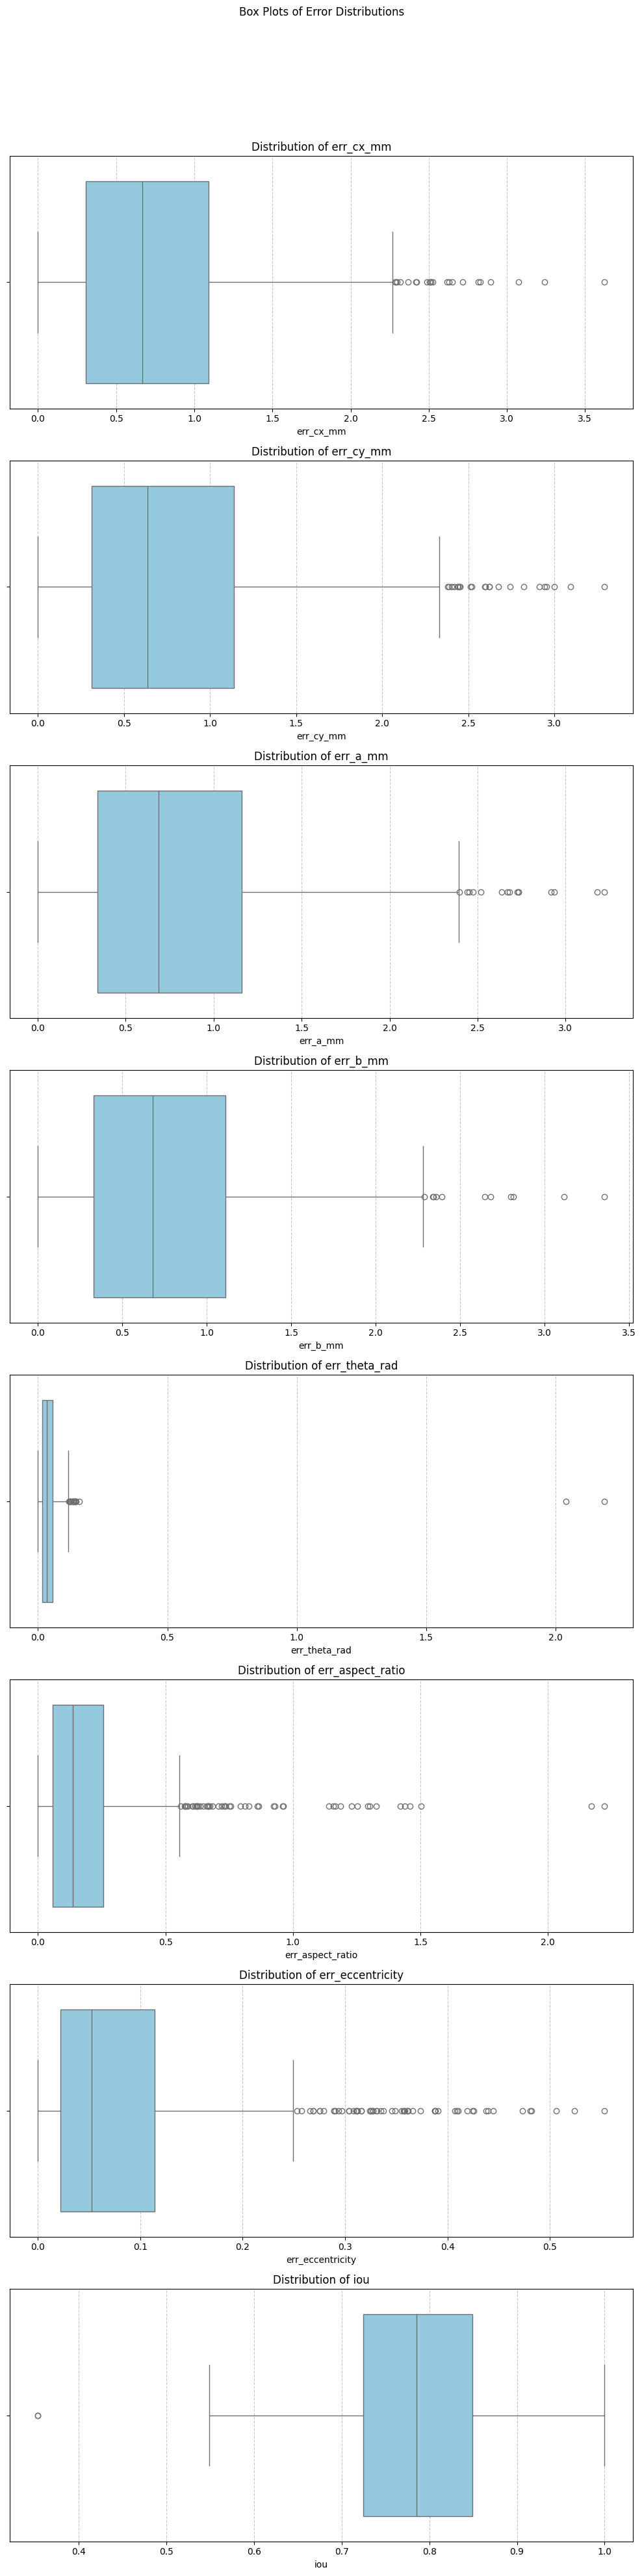


Programmatic outlier detection using IQR for 'err_cx_mm':
Found 22 outliers in 'err_cx_mm' using IQR method:


,image_id,err_cx_mm
1,1,2.3167
17,17,2.5056
94,94,2.5262
143,143,3.6255
176,176,2.4208
286,286,2.8150
295,295,2.5140
312,312,2.3679
393,393,2.8274
430,430,2.4890


In [8]:
if df_errors is not None:
    # Generate box plots for each error column
    print("\nGenerating box plots for error distributions...")
    fig, axes = plt.subplots(len(error_cols), 1, figsize=(10, 5 * len(error_cols)))
    fig.suptitle('Box Plots of Error Distributions', y=1.02)

    for i, col in enumerate(error_cols):
        sns.boxplot(x=df_errors[col], ax=axes[i], color='skyblue')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

    # Example of programmatic outlier detection using IQR for 'err_cx_mm'
    print("\nProgrammatic outlier detection using IQR for 'err_cx_mm':")
    Q1 = df_errors['err_cx_mm'].quantile(0.25)
    Q3 = df_errors['err_cx_mm'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_errors[(df_errors['err_cx_mm'] < lower_bound) | (df_errors['err_cx_mm'] > upper_bound)]

    if not outliers.empty:
        print(f"Found {len(outliers)} outliers in 'err_cx_mm' using IQR method:")
        display(outliers[['image_id', 'err_cx_mm']])
    else:
        print("No outliers found in 'err_cx_mm' using the IQR method.")


In [ ]:
import os
print(os.listdir('/content/'))

# If ElGenV1_Ellipses_1000 exists, list its contents
if 'ElGenV1_Ellipses_1000' in os.listdir('/content/'):
    print(os.listdir('/content/ElGenV1_Ellipses_1000'))

['.config', 'ElGenV1_Ellipses_1000_BM.zip', 'sample_data']


In [2]:
import zipfile
import os

zip_path = "/content/ElGenV1_Ellipses_1000_BM.zip"
extract_path = "/content/"

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Extracted {zip_path} to {extract_path}")
else:
    print(f"Error: Zip file not found at {zip_path}")

Extracted /content/ElGenV1_Ellipses_1000_BM.zip to /content/
